## Curso Python para Economistas
### Trabajo Práctico Nº 5

### Fecha de entrega:
Viernes 28/10 a las 17:00 hs

### Modalidad de entrega y trabajo
- Este TP es **grupal**.
- Un miembro del grupo debe crear un repositorio **privado** en GitHub, y dar acceso a sus compañeros y a los 5 profesores.
- **Todos los miembros del grupo deben haber hecho al menos un commit con contribuciones sustanciales**.
- Corroborar que el nombre de usuario que tienen configurado para `git` es el mismo nombre de usuario de GitHub. Para hacer esto, se puede correr `git config --list` en su `cmd` o terminal.
- Cuando hayan hecho ese último commit, copien la URL para clonar su repositorio y péguenla en
[la Google Sheet], en la hoja del TP5. Agreguen los nombres de los integrantes del grupo. Al ser un repositorio privado, solo los colaboradores habilitados podrán clonarlo.
- Al finalizar el trabajo práctico deben hacer un último commit y push en su repositorio de GitHub con el mensaje `"Entrega final del TP5"`. Antes de la fecha y hora de entrega pueden hacer cuantos cambios quieran en el repositorio, pero luego de la hora de corte no deben hacer más cambios. Si un commit con el mensaje anterior se realiza luego de la hora de entrega, se supondrá que la entrega tardía fue intencional y se utilizarán los días de gracia. La última versión en el repositorio es la que será evaluada. Para esto es importante que no completen el Google Sheet hasta que no hayan finalizado el TP, como tampoco hacer pushes posteriores a la entrega.

IMPORTO DIVERSOS PAQUETES QUE SERÁN UTILIZADOS A LO LARGO DEL TP

In [120]:
import os
import re
import string
import pandas as pd
import numpy as np
import tweepy

import sys
#!{sys.executable} -m pip install wordcloud
from wordcloud import WordCloud
#!{sys.executable} -m pip install Pillow
from PIL import Image
import matplotlib.pyplot as plt

from textblob import TextBlob
from datetime import datetime
from datetime import timezone as tz
#!{sys.executable} -m pip install sentiment_analysis_spanish
#from sentiment_analysis_spanish import sentiment_analysis

import nltk
#nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

DEFINO ALGUNAS FUNCIONES QUE SERÁN UTILIZADAS A LO LARGO DEL TRABAJO PRÁCTICO

In [121]:
# FUNCIÓN "GET_ALL_TWEETS"

def get_all_tweets(screen_name, start_date):

    '''
    Esta función recibe el nombre de la persona de quien queremos extraer los tweets y devuelve una lista con todos los tweets y sus datos.
    Input:
      screen_name (str): nombre de la persona en twitter.
    Output:
      all_tweets (lista): lista con todos los tweets extraídos.
    '''

    # Solicito los 200 tweets más recientes (200 es el máximo permitido en count)
    new_tweets = api.user_timeline(screen_name=screen_name, tweet_mode="extended", count=200)

    # Creo una lista para almacenar TODOS los tweets y agrego los recién extraidos
    all_tweets = []
    all_tweets.extend(new_tweets)

    # Guardo el id del último tweet extraído 
    oldest = all_tweets[-1].id 

    # Extraigo tweets de a 200 hasta que no haya más
    while len(new_tweets) > 0 and all_tweets[-1].created_at > start_date:
        # Solicito 200 tweets más y los agrego a la lista de "all_tweets"
        new_tweets = api.user_timeline(screen_name=screen_name, tweet_mode="extended", count=200, max_id=oldest-1)
        all_tweets.extend(new_tweets)
        # Actualizo el id del último tweet extraído
        oldest = all_tweets[-1].id 
        print("Hasta ahora se han extraído %s tweets" % len(all_tweets))

    return all_tweets

In [122]:
# FUNCIÓN "SAVE_TWEETS_TEXT"

def save_tweets_text(all_tweets, csv_file=None):

    '''
    Esta función guarda los tweets en un data frame y, si se especifica un archivo .csv, también se guardarán ahí. 
    Input:
        all_tweets (lista): lista con tweets y sus datos.
        csv_file ('str'): nombre del archivo .csv.
    Output:
        df_all_tweets (df): tweets ordenados en una tabla con datos seleccinados.
    '''

    all_tweets_selection = []

    for tweet in all_tweets:
        one_tweet = [tweet.id_str, tweet.created_at, tweet.full_text, tweet.retweeted, tweet.favorite_count, tweet.in_reply_to_screen_name]
        all_tweets_selection.append(one_tweet)

    df_all_tweets = pd.DataFrame(all_tweets_selection)
    df_all_tweets.columns = ["id_str", "created_at", "text", "retweeted", "favorite_count", "in_reply_to_screen_name"]
    if csv_file:
        df_all_tweets.to_csv(csv_file, index=False, encoding="utf-8")

    return df_all_tweets

In [123]:
# FUNCIÓN "CLEAN_TWEET"

def clean_tweet(tweet):

    '''
    Esta función limpia el texto de un tweet. Elimina caracteres especÍficos que
    se utilizan en twitter como los de re-tweets, los links y otros Non-ASCII. Devuelve el texto "limpio".
    Input:
        tweet (str): Texto del tweet original.
    Output:
        tweet (str): Texto del tweet limpiado.
    '''

    # Elimino los links
    tweet = re.sub(r"https\S+", "", tweet)
    # Elimino caracteres de re-tweets
    tweet = re.sub(r"^RT .*:", "", tweet)
    tweet = re.sub(r"@\S+", "", tweet)
    tweet = re.sub(r":", "", tweet)
    tweet = re.sub(r"‚Ä¶", "", tweet)
    # Reemplazo caracteres non-ASCII con espacio
    tweet = re.sub(r"[^\x00-\x7F]+"," ", tweet)

    return tweet

ABRO ARCHIVO .txt CON LAS KEYS DE TWITTER

In [124]:
# Creo variables que contienen mis claves de autenticación con la API
with open("twitter_keys.txt") as tw_k:
    consumer_key = tw_k.readline().strip()
    consumer_secret = tw_k.readline().strip()
    access_key = tw_k.readline().strip()
    access_secret = tw_k.readline().strip()

# Paso mis credenciales de twitter a tweepy
auth = tweepy.OAuthHandler(consumer_key, consumer_secret)
auth.set_access_token(access_key, access_secret)
api = tweepy.API(auth)

DECLARO EMOTICONES Y EMOJIS

In [125]:
# Emoticones Contentos
emoticons_happy = set([
    ':-)', ':)', ';)', ':o)', ':]', ':3', ':c)', ':>', '=]', '8)', '=)', ':}',
    ':^)', ':-D', ':D', '8-D', '8D', 'x-D', 'xD', 'X-D', 'XD', '=-D', '=D',
    '=-3', '=3', ':-))', ":'-)", ":')", ':*', ':^*', '>:P', ':-P', ':P', 'X-P',
    'x-p', 'xp', 'XP', ':-p', ':p', '=p', ':-b', ':b', '>:)', '>;)', '>:-)',
    '<3'
    ])

# Emoticones Tristes
emoticons_sad = set([
    ':L', ':-/', '>:/', ':S', '>:[', ':@', ':-(', ':[', ':-||', '=L', ':<',
    ':-[', ':-<', '=\\', '=/', '>:(', ':(', '>.<', ":'-(", ":'(", ':\\', ':-c',
    ':c', ':{', '>:\\', ';('
    ])

# Combino emoticones contentos y tristes
emoticons = emoticons_happy.union(emoticons_sad)

# Emoji Patterns (todos)
emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # símbolos & pictogramas
                           u"\U0001F680-\U0001F6FF"  # transporte & símbolos mapas
                           u"\U0001F1E0-\U0001F1FF"  # banderas (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)

# Emoji Patterns Contentos
emoji_pattern_happy = re.compile("["
                           u"\U0001F600-\U0001F60F"  # emoticons
                           u"\U0001F617-\U0001F61D"  # emoticons
                           "]+", flags=re.UNICODE)

# Emoji Patterns Tristes
emoji_pattern_sad = re.compile("["
                           u"\U0001F610-\U0001F616"  # emoticons
                           u"\U0001F620-\U0001F62F"  # emoticons
                           "]+", flags=re.UNICODE)

#### Ejercicio 1:
Creen una función que limpie cualquier tipo de texto. Esta debe eliminar emoticones, emojis, palabras vacías (también llamadas stop words en la libreria de nltk), puntuaciones, etc. 

Además, cuando el parametro is_tweet este seteado en True, la función debe eliminar indicaciones de retweets, links y cualquier otra particularidad de los tweets que crean relevante eliminar. 

Prueben el funcionamiento de su función con el texto a continuación

In [126]:
texto = "She's got a smile :) that it seems to me. Reminds me of childhood memories. Where everything was as fresh as the bright blue sky. Now and then when I see her face \U0001F600 . She takes me away to that special place. And if I stare too long, I'd probably break down and cry :'( Whoa, oh, oh. Sweet child o' mine. Whoa, oh, oh, oh. Sweet love of mine. She's got eyes of the bluest skies. As if they thought of rain. I'd hate to look into those eyes and see an ounce of pain. Her hair reminds me of a warm safe place. Where as a child I'd hide. And pray for the thunder and the rain to quietly pass me by. Where do we go? Where do we go now? Where do we go? Ooh, oh, where do we go? Where do we go now? \U0001F3B8 https://www.youtube.com/watch?v=1w7OgIMMRc4"
print(texto)

She's got a smile :) that it seems to me. Reminds me of childhood memories. Where everything was as fresh as the bright blue sky. Now and then when I see her face 😀 . She takes me away to that special place. And if I stare too long, I'd probably break down and cry :'( Whoa, oh, oh. Sweet child o' mine. Whoa, oh, oh, oh. Sweet love of mine. She's got eyes of the bluest skies. As if they thought of rain. I'd hate to look into those eyes and see an ounce of pain. Her hair reminds me of a warm safe place. Where as a child I'd hide. And pray for the thunder and the rain to quietly pass me by. Where do we go? Where do we go now? Where do we go? Ooh, oh, where do we go? Where do we go now? 🎸 https://www.youtube.com/watch?v=1w7OgIMMRc4


In [127]:
def clean_text(text, is_tweet=False):

    '''
    Esta función limpia el caulquier texto. Elimina emoticones, emojis, palabras
    vacías (también llamadas stop words en la librería de nltk), links, puntuaciones
    indicaciones de retweets, etc. Devuelve sólo un string sólo con las palabras  
    con mayor contenido para el análisis.
    Input:
        text (str): texto original.
        is_tweet (bool): si el texto es un tweet, este parámetro debe setearse a 
                         True para que también se limpie el texto con los 
                         caracteres más especificos de twitter (usa clean_tweet).
    Output:
        text (str): texto limpiado.
    '''

    # Paso todo el texto a minúscula
    text = text.lower()
    # Si es un tweet, saco caracteres específicos que sean de twitter (retweets, links, etc.)
    if is_tweet:
        text = clean_tweet(text)
    # Saco los emojis
    text = re.sub(emoji_pattern, "", text)
    # Saco los links
    text = re.sub(r"https\S+", "", text)
    # Saco los signos de puntuación
    text = "".join([i for i in text if i not in string.punctuation])
    # Saco las palabras vacías ("stop words")
    text = " ".join([i for i in text.split() if i not in set(stopwords.words("english"))])
 
    return text

In [128]:
# Pruebo si la función funciona correctamente
print("TEXTO ORIGINAL:\n", texto)
texto_limpio = clean_text(texto)
print("\nTEXTO LIMPIO:\n", texto_limpio)

TEXTO ORIGINAL:
 She's got a smile :) that it seems to me. Reminds me of childhood memories. Where everything was as fresh as the bright blue sky. Now and then when I see her face 😀 . She takes me away to that special place. And if I stare too long, I'd probably break down and cry :'( Whoa, oh, oh. Sweet child o' mine. Whoa, oh, oh, oh. Sweet love of mine. She's got eyes of the bluest skies. As if they thought of rain. I'd hate to look into those eyes and see an ounce of pain. Her hair reminds me of a warm safe place. Where as a child I'd hide. And pray for the thunder and the rain to quietly pass me by. Where do we go? Where do we go now? Where do we go? Ooh, oh, where do we go? Where do we go now? 🎸 https://www.youtube.com/watch?v=1w7OgIMMRc4

TEXTO LIMPIO:
 shes got smile seems reminds childhood memories everything fresh bright blue sky see face takes away special place stare long id probably break cry whoa oh oh sweet child mine whoa oh oh oh sweet love mine shes got eyes bluest sk

#### Ejercicio 2:
Construyan una función que reciba una fecha a testear y dos fechas limite. La función debe chequear si la fecha a testear cae entre las dos fechas limites y devolver True cuando lo haga y False cuando no. 

Prueben si su función anda como esperaban con las fechas sugeridas a continuación (y con otras opciones de date para asegurarse que funcione bien):

In [129]:
date = datetime.strptime("2020-11-03", "%Y-%m-%d")
start_time = datetime.strptime("2020-10-20", "%Y-%m-%d")
end_time = datetime.strptime("2020-11-18", "%Y-%m-%d")

In [130]:
def filter_year_and_month(date, start_time, end_time):

    '''
    Recibe una fecha y devuelve True si la fecha de la fila está dentro de los días especificados como inicio y fin, caso contrario False.
    '''

    if date > start_time and date < end_time:
        return True
    else:
        return False

In [131]:
# Pruebo si la función funciona correctamente (con diferentes opciones de date)
date1 = datetime.strptime("2020-11-03", "%Y-%m-%d")
date2 = datetime.strptime("2020-10-19", "%Y-%m-%d")
date3 = datetime.strptime("2020-11-19", "%Y-%m-%d")
dates = [date1, date2, date3]
for date in dates:
    prueba = filter_year_and_month(date, start_time, end_time)
    print(date, ":", prueba)

2020-11-03 00:00:00 : True
2020-10-19 00:00:00 : False
2020-11-19 00:00:00 : False


#### Ejercicio 3:
Construyan una función que genere un indicador de sentimiento positivo o negativo.

Si estan trabajando con tweets en inglés pueden usar sentiment.polarity de TextBlob.

Si estan trabajando con tweets en Español pueden usar sentiment_analysis de sentiment_analysis_spanish

Prueben su función con el texto del ejercicio 1.

In [132]:
def generate_sentiment(text, is_tweet=False):

    '''
    Esta función limpia el texto y analiza el sentimiento.
    Input:
        text (str): texto a limpiar y analizar.
    Output:
         sentimiento (float): cuanto menor sea el número, más negativo es el texto y, cuanto mayor, más positivo.
    '''

    # Limpio el texto
    text = clean_text(text, is_tweet)

    # Calculo el sentimiento con el método TextBlob
    blob = TextBlob(text)
    sentiment = blob.sentiment
    polarity = sentiment.polarity

    return polarity

In [133]:
# Pruebo si la función funciona correctamente
polarity = generate_sentiment(texto)
print("El indicador de sentimiento del texto es:", polarity)

El indicador de sentimiento del texto es: 0.23901098901098902


#### Ejercicio 4:
Construyan una función que reciba un texto y detecte caritas creadas con caracteres y caritas de UNICODE. Debe devolver una tupla que contenga dos booleanos. El primer booleano indicará si había (True) o no (False) caritas tristes y el segundo si había (True) o no (False) caritas felices.

Prueben esta función con el texto del ejercicio 1.

In [134]:
def detect_sad_happy_icons(text):

    '''
    Esta función detecta caritas creadas con caracteres y caritas de UNICODE.
    Input:
        text (str): texto en el cual buscar las caritas.
    Output:
        sad, happy (bool, bool): Indican si había (True) o no (False) caritas tristes y felices.
    '''

    # Inicializo variables
    sad = False
    happy = False

    # Busco emojis tristes en el texto
    if re.search(emoji_pattern_sad, text):
        sad = True

    # Busco emojis contentos en el texto
    if re.search(emoji_pattern_happy, text):
        happy = True

    # Busco emoticones tristes en el texto
    for s in emoticons_sad:
        s = s.replace("\\","\\\\")
        s = s.replace(")","\)")
        s = s.replace("(","\(")
        s = s.replace("[","\[")
        s = s.replace("]","\]")
        s = s.replace("*","\*")
        s = s.replace("|","\|")
        regex = re.compile(s)
        if regex.search(text):
            sad = True

    # Busco emoticones contentos en el texto
    for h in emoticons_happy:
        h = h.replace("\\","\\\\")
        h = h.replace(")","\)")
        h = h.replace("(","\(")
        h = h.replace("[","\[")
        h = h.replace("]","\]")
        h = h.replace("*","\*")
        regex = re.compile(h)
        if regex.search(text):
            happy = True
 
    return (sad, happy)

In [135]:
# Pruebo si la función funciona correctamente
print("TEXTO:\n", texto)
tupla = detect_sad_happy_icons(texto)
print("\nTUPLA:\n", tupla)

TEXTO:
 She's got a smile :) that it seems to me. Reminds me of childhood memories. Where everything was as fresh as the bright blue sky. Now and then when I see her face 😀 . She takes me away to that special place. And if I stare too long, I'd probably break down and cry :'( Whoa, oh, oh. Sweet child o' mine. Whoa, oh, oh, oh. Sweet love of mine. She's got eyes of the bluest skies. As if they thought of rain. I'd hate to look into those eyes and see an ounce of pain. Her hair reminds me of a warm safe place. Where as a child I'd hide. And pray for the thunder and the rain to quietly pass me by. Where do we go? Where do we go now? Where do we go? Ooh, oh, where do we go? Where do we go now? 🎸 https://www.youtube.com/watch?v=1w7OgIMMRc4

TUPLA:
 (True, True)


#### Ejercicio 5:
Elijan la cuenta de twitter de algún usuario público y algún periodo o evento que pueda haber sido importante para esa persona/cuenta y le pueda haber hecho cambiar el sentimiento de sus post. Expliquen muy brevemente su elección.

Repitan los pasos que hemos realizado en clase para construir la tabla llamada `df_all_tweets` (la construimos en el ejercicio 1). 

No es necesario que copien las funciones vistas durante la clase sincrónica. Simplemente llamenlas a continuación con la nueva cuenta de twitter que quieran analizar. 

In [136]:
# Creo dataframe con información de los tweets de Elon Musk desde el 01/09/2022
df_all_tweets = save_tweets_text(get_all_tweets("elonmusk", datetime(2022, 9, 1, 0, 0, 0, tzinfo=tz.utc)), csv_file="tweets_musk.csv")

# Inspecciono el dataframe
df_all_tweets

Hasta ahora se han extraído 400 tweets
Hasta ahora se han extraído 600 tweets
Hasta ahora se han extraído 800 tweets


,id_str,created_at,text,retweeted,favorite_count,in_reply_to_screen_name
0,1586703490650284032,2022-10-30 12:56:06+00:00,RT @Tesla: 20k Model Y built at Giga Texas to ...,False,0,None
1,1586698051606880258,2022-10-30 12:34:29+00:00,@KingJames https://t.co/ZdI2nTqlqw,False,20460,KingJames
2,1586690742151307264,2022-10-30 12:05:26+00:00,@Neuro_Skeptic https://t.co/gSjeJniK4u,False,41100,Neuro_Skeptic
3,1586689827721736192,2022-10-30 12:01:48+00:00,@itsALLrisky @spideycyp_155 @WholeMarsBlog Twe...,False,9372,itsALLrisky
4,1586688122628108288,2022-10-30 11:55:02+00:00,@TonyadeVitti @spideycyp_155 @WholeMarsBlog Pr...,False,9301,TonyadeVitti
...,...,...,...,...,...,...
795,1564532904998289409,2022-08-30 08:38:06+00:00,@teslaownersSV @SpaceX Ancient times,False,26648,teslaownersSV
796,1564300172753915904,2022-08-29 17:13:19+00:00,@teslaownersSV It will grow by at least 5 to 1...,False,40515,teslaownersSV
797,1564075005691961345,2022-08-29 02:18:35+00:00,"@WholeMarsBlog First few days, just 1k owners,...",False,8523,WholeMarsBlog
798,1564073223289028614,2022-08-29 02:11:30+00:00,@MuskUniversity Good to ask yourself this often,False,20388,MuskUniversity


##### Expliquen muy brevemente su elección de cuenta y período acá:

Se selecciono como cuenta de twitter la de:
# `Elon Musk`
Durante el último año, el empresario estuvo involucrado en rumores sobre la compra de una parte mayoritaria de las acciones de Twitter. En particular, a comienzos de octubre, estos rumores parecen haberse confirmado. Es por ello que me parece interesante analizar si, durante ese período, el sentimiento de sus post se modificó. Para el análisis de los tweets, se toma como inicio septiembre de 2022, de manera de obtener un período previo a que la noticia tomó fuerza nuevamente durante octubre, y poder realizar un análisis pre y post evento.

#### Ejercicio 6:
Construyan una función que utilice las 4 funciones creadas previamente (ej.1 al 4). Los argumentos de esta función deben ser un df y el rango de fechas que quieren analizar. 

Esta función debe limpiar el texto de los tweets, filtrar los tweets que correspondan a fechas dentro del rango que ustedes eligieron en el punto 5, calcular el sentimiento del texto y buscar si tiene caritas.

Finalmente, la función debe devolver un data frame que solo tenga tweets posteados en el periodo que ustedes eligieron, y que tenga 4 nuevas columnas, una para el texto limpio, otra para el sentimiento y dos más que indiquen si el texto tenía caritas tristes y felices. 

Utilicen esta función sobre el dataframe `df_all_tweets` que armaron en el punto 5. 

In [137]:
def add_sentiment(df, start_time, end_time):

    '''
    Esta función debe limpiar el texto de los tweets, filtrar los tweets que
    correspondan al período entre start_time y end_time, calcular el sentimiento 
    del texto y buscar si tiene caritas.
    Input:
        df (dataframe): tabla con los tweets en una columa llamada text.
        start_time (datetime): fecha del tweet más antiguo a conservar.
        end_time (datetime): fecha del tweet más reciente a conservar.
    Output:
        df (dataframe): df actualizado con el filtro y las nuevas columnas (éstas
                        deben ser: clean_text, sentimiento, sad_face, happy_face).
    '''

    # Creo nuevas columnas
    df_cleaned = df.copy()
    df_cleaned["clean_text"] = ""
    df_cleaned["drop"] = False
    df_cleaned["sad_face"] = False
    df_cleaned["happy_face"] = False

    for i, tw in df_cleaned.iterrows():

        # Limpio el texto de los tweets
        df_cleaned.at[i, "clean_text"] = clean_text(tw["text"], True)

        # Filtro los tweets que corresponden a fechas dentro del rango establecido
        if filter_year_and_month(tw["created_at"], start_time, end_time) == False:
            df_cleaned.at[i, "drop"] = True

        # Busco si el texto tiene caritas tristes
        if detect_sad_happy_icons(tw["text"])[0]:
            df_cleaned.at[i, "sad_face"] = True

        # Busco si el texto tiene caritas contentas
        if detect_sad_happy_icons(tw["text"])[1]:
            df_cleaned.at[i, "happy_face"] = True

        # Calculo el sentimiento
        df_cleaned.at[i, "sentiment"] = generate_sentiment(tw["text"], is_tweet=True)

    df_cleaned = df_cleaned[df_cleaned["drop"] == False]
    df_cleaned.drop(["drop"], axis=1, inplace=True)
    df_cleaned = df_cleaned.reset_index(drop=True)

    return df_cleaned

In [138]:
# Pruebo si la función funciona correctamente
start_time = datetime(2022, 9, 1, 0, 0, 0, tzinfo=tz.utc)
end_time = datetime(2022, 10, 31, 0, 0, 0, tzinfo=tz.utc)
df_all_tweets_cleaned=add_sentiment(df_all_tweets, start_time, end_time)
df_all_tweets_cleaned.head(10)

,id_str,created_at,text,retweeted,favorite_count,in_reply_to_screen_name,clean_text,sad_face,happy_face,sentiment
0,1586703490650284032,2022-10-30 12:56:06+00:00,RT @Tesla: 20k Model Y built at Giga Texas to ...,False,0,None,rt 20k model built giga texas date,False,False,0.000000
1,1586698051606880258,2022-10-30 12:34:29+00:00,@KingJames https://t.co/ZdI2nTqlqw,False,20460,KingJames,,False,False,0.000000
2,1586690742151307264,2022-10-30 12:05:26+00:00,@Neuro_Skeptic https://t.co/gSjeJniK4u,False,41100,Neuro_Skeptic,,False,False,0.000000
3,1586689827721736192,2022-10-30 12:01:48+00:00,@itsALLrisky @spideycyp_155 @WholeMarsBlog Twe...,False,9372,itsALLrisky,tweeps twits going forward latter vastly gravitas,False,False,0.000000
4,1586688122628108288,2022-10-30 11:55:02+00:00,@TonyadeVitti @spideycyp_155 @WholeMarsBlog Pr...,False,9301,TonyadeVitti,pretty much,False,False,0.225000
5,1586686935518498816,2022-10-30 11:50:19+00:00,@spideycyp_155 @WholeMarsBlog There seem to be...,False,32853,spideycyp_155,seem 10 people managing every one person coding,False,False,0.000000
6,1586686368033345539,2022-10-30 11:48:04+00:00,But Management 201 is such a tantalizing carrot …,False,121695,elonmusk,management 201 tantalizing carrot,False,False,0.000000
7,1586685737591709696,2022-10-30 11:45:33+00:00,@WholeMarsBlog My title is Chief Twit right th...,False,64271,WholeMarsBlog,title chief twit right bio idea ceo,False,False,0.285714
8,1586685433965989888,2022-10-30 11:44:21+00:00,@kerrikgray 💯,False,20075,kerrikgray,,False,False,0.000000
9,1586685077680889856,2022-10-30 11:42:56+00:00,So demanding to allow a mere 30 days to learn ...,False,129374,elonmusk,demanding allow mere 30 days learn priceless i...,False,False,0.250000


#### Ejercicio 7: 
Utilizado un criterio arbitratio creado por ustedes, agreguen una nueva columna al dataframe que se llame `indice_sentimiento` y combine las columnas `sentimiento`, `sad_face`, `happy_face` (con la ponderación que ustedes elijan).

Expliquen muy brevemente la elección de ponderación que hicieron.

In [139]:
df_all_tweets_cleaned["indice_sentimiento"] = 1*df_all_tweets_cleaned.sentiment + 0.2*df_all_tweets_cleaned.happy_face.apply(int) - 0.2*df_all_tweets_cleaned.sad_face.apply(int)
df_all_tweets_cleaned.head(10)

,id_str,created_at,text,retweeted,favorite_count,in_reply_to_screen_name,clean_text,sad_face,happy_face,sentiment,indice_sentimiento
0,1586703490650284032,2022-10-30 12:56:06+00:00,RT @Tesla: 20k Model Y built at Giga Texas to ...,False,0,None,rt 20k model built giga texas date,False,False,0.000000,0.000000
1,1586698051606880258,2022-10-30 12:34:29+00:00,@KingJames https://t.co/ZdI2nTqlqw,False,20460,KingJames,,False,False,0.000000,0.000000
2,1586690742151307264,2022-10-30 12:05:26+00:00,@Neuro_Skeptic https://t.co/gSjeJniK4u,False,41100,Neuro_Skeptic,,False,False,0.000000,0.000000
3,1586689827721736192,2022-10-30 12:01:48+00:00,@itsALLrisky @spideycyp_155 @WholeMarsBlog Twe...,False,9372,itsALLrisky,tweeps twits going forward latter vastly gravitas,False,False,0.000000,0.000000
4,1586688122628108288,2022-10-30 11:55:02+00:00,@TonyadeVitti @spideycyp_155 @WholeMarsBlog Pr...,False,9301,TonyadeVitti,pretty much,False,False,0.225000,0.225000
5,1586686935518498816,2022-10-30 11:50:19+00:00,@spideycyp_155 @WholeMarsBlog There seem to be...,False,32853,spideycyp_155,seem 10 people managing every one person coding,False,False,0.000000,0.000000
6,1586686368033345539,2022-10-30 11:48:04+00:00,But Management 201 is such a tantalizing carrot …,False,121695,elonmusk,management 201 tantalizing carrot,False,False,0.000000,0.000000
7,1586685737591709696,2022-10-30 11:45:33+00:00,@WholeMarsBlog My title is Chief Twit right th...,False,64271,WholeMarsBlog,title chief twit right bio idea ceo,False,False,0.285714,0.285714
8,1586685433965989888,2022-10-30 11:44:21+00:00,@kerrikgray 💯,False,20075,kerrikgray,,False,False,0.000000,0.000000
9,1586685077680889856,2022-10-30 11:42:56+00:00,So demanding to allow a mere 30 days to learn ...,False,129374,elonmusk,demanding allow mere 30 days learn priceless i...,False,False,0.250000,0.250000


##### Expliquen muy brevemente su elección acá:

Decido tomar el sentimiento original ponderado por 1 y, luego, con una ponderación de igual magnitud (20%) pero en sentido contrario, se incorpora la aparición de caritas tristes y contentas. De esta manera, un tweet que contenga ambas caritas tendrá un index_sentiment igual a su sentiment, pero un tweet que sólo contenga una de las dos caritas tendrá un index_sentiment mayor (si aparece carita contenta) o menor (si aparece carita triste) a su sentiment.

#### Ejercicio 8: 
Elijan un umbral (por ejemplo, si su `indice_sentimiento` va de 0 a 1 el umbral podía ser el 0.5). Agreguen al df una nueva columna llamada `positivo` que tome valores:
- 1 cuando el tweet tiene polarity >= umbral, 
- 0 cuando el tweet tiene polarity < umbral 

In [140]:
# Utilizo como umbral el punto medio entre el mínimo y el máximo de la columna "indice_sentimiento"
min_is = df_all_tweets_cleaned["indice_sentimiento"].min()
max_is = df_all_tweets_cleaned["indice_sentimiento"].max()
umbral = (min_is + max_is) / 2
print("UMBRAL ESTABLECIDO", umbral)

# Creo la columna "positivo" como True o False en función de si se cumple que el valor de "indice_sentimiento" es mayor o igual al umbral establecido
df_all_tweets_cleaned["positivo"] = df_all_tweets_cleaned["indice_sentimiento"] >= umbral

# Paso los valores "False" y "True" a "0" y "1", respectivamente
df_all_tweets_cleaned["positivo"] = df_all_tweets_cleaned["positivo"].apply(int)

# Inspecciono el dataframe
df_all_tweets_cleaned.head(10)

UMBRAL ESTABLECIDO 0.09999999999999998


,id_str,created_at,text,retweeted,favorite_count,in_reply_to_screen_name,clean_text,sad_face,happy_face,sentiment,indice_sentimiento,positivo
0,1586703490650284032,2022-10-30 12:56:06+00:00,RT @Tesla: 20k Model Y built at Giga Texas to ...,False,0,None,rt 20k model built giga texas date,False,False,0.000000,0.000000,0
1,1586698051606880258,2022-10-30 12:34:29+00:00,@KingJames https://t.co/ZdI2nTqlqw,False,20460,KingJames,,False,False,0.000000,0.000000,0
2,1586690742151307264,2022-10-30 12:05:26+00:00,@Neuro_Skeptic https://t.co/gSjeJniK4u,False,41100,Neuro_Skeptic,,False,False,0.000000,0.000000,0
3,1586689827721736192,2022-10-30 12:01:48+00:00,@itsALLrisky @spideycyp_155 @WholeMarsBlog Twe...,False,9372,itsALLrisky,tweeps twits going forward latter vastly gravitas,False,False,0.000000,0.000000,0
4,1586688122628108288,2022-10-30 11:55:02+00:00,@TonyadeVitti @spideycyp_155 @WholeMarsBlog Pr...,False,9301,TonyadeVitti,pretty much,False,False,0.225000,0.225000,1
5,1586686935518498816,2022-10-30 11:50:19+00:00,@spideycyp_155 @WholeMarsBlog There seem to be...,False,32853,spideycyp_155,seem 10 people managing every one person coding,False,False,0.000000,0.000000,0
6,1586686368033345539,2022-10-30 11:48:04+00:00,But Management 201 is such a tantalizing carrot …,False,121695,elonmusk,management 201 tantalizing carrot,False,False,0.000000,0.000000,0
7,1586685737591709696,2022-10-30 11:45:33+00:00,@WholeMarsBlog My title is Chief Twit right th...,False,64271,WholeMarsBlog,title chief twit right bio idea ceo,False,False,0.285714,0.285714,1
8,1586685433965989888,2022-10-30 11:44:21+00:00,@kerrikgray 💯,False,20075,kerrikgray,,False,False,0.000000,0.000000,0
9,1586685077680889856,2022-10-30 11:42:56+00:00,So demanding to allow a mere 30 days to learn ...,False,129374,elonmusk,demanding allow mere 30 days learn priceless i...,False,False,0.250000,0.250000,1


#### Ejercicio 9: 
Realicen un gráfico de nube con las palabras de todos los textos limpios de los tweets que tienene `positivo` == 1

In [141]:
# Genero dos variables con todas las palabras que aparecen en la columna "text_clean" del dataframe, particionado en función de la columna "positivo"
texto_musk_1 = " ".join(df_all_tweets_cleaned[df_all_tweets_cleaned["positivo"] == 1]["clean_text"])
texto_musk_0 = " ".join(df_all_tweets_cleaned[df_all_tweets_cleaned["positivo"] == 0]["clean_text"])

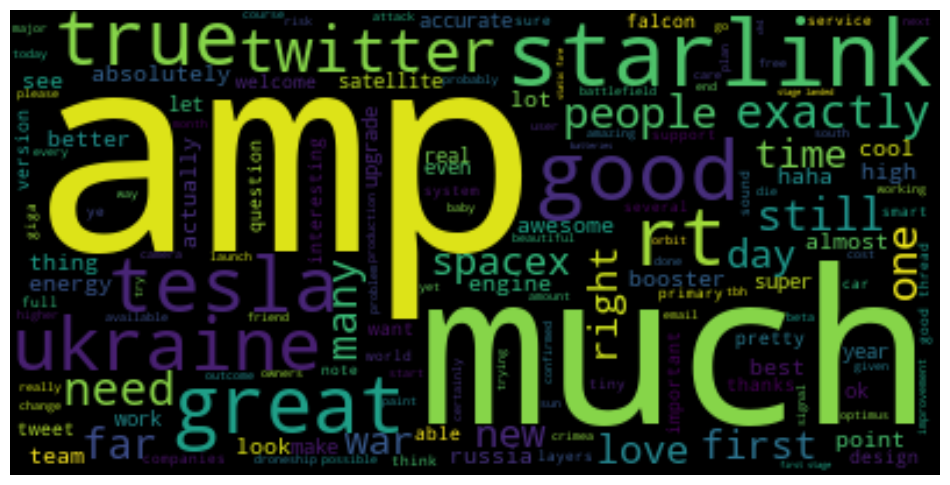

In [142]:
# Genero una gráfico de nube con las palabras de todos los textos limpios de los tweets que tienen positivo == 1
wordcloud = WordCloud().generate(texto_musk_1)
plt.figure(figsize=(12,9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

#### Ejercicio 10: 
Realicen un gráfico de nube con las palabras de todos los textos limpios de los tweets que tienene `positivo` == 0

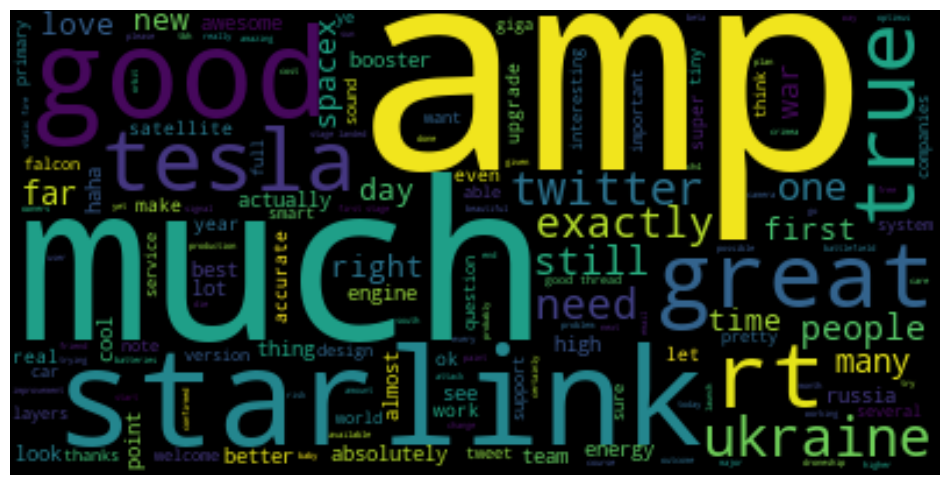

In [143]:
# Genero una gráfico de nube con las palabras de todos los textos limpios de los tweets que tienen positivo == 0
wordcloud = WordCloud().generate(texto_musk_1)
plt.figure(figsize=(12,9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()